# E-Commerce Customer Segmentation
In this project, we will build a machine learning model to segment e-commerce customers based on their purchasing behavior. 

Customer segmentation is highly valuable for targeted marketing, personalized recommendations, and customer retention strategies. We will use **K-Means Clustering**, an unsupervised machine learning algorithm, to group customers into distinct segments.

### Project Steps:
1. **Data Generation**: Create a realistic synthetic e-commerce dataset.
2. **Exploratory Data Analysis (EDA)**: Understand the feature distributions.
3. **Data Preprocessing**: Standardize the data for K-Means.
4. **Machine Learning**: Determine the optimal number of clusters and train the model.
5. **Dimensionality Reduction**: Use PCA to visualize the high-dimensional clusters in 2D.
6. **Business Interpretation**: Extract actionable insights from the segments.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Generation
We will generate a dataset representing 1000 customers. The features include:
* `Customer_ID`: Unique identifier
* `Age`: Customer's age (18 - 70)
* `Annual_Income_k$`: Annual income in thousands of dollars (20 - 150)
* `Total_Spend_k$`: Total amount spent on the platform (1 - 100)
* `Purchase_Frequency`: Number of purchases made in the last year (1 - 50)

In [41]:
# Set random seed for reproducibility
np.random.seed(42)

n_customers = 1000

# Generating distinct groups to make clustering effective
# Group 1: Young, low income, high spend (Bargain Hunters/Impulse Buyers)
age_1 = np.random.normal(25, 5, 250)
inc_1 = np.random.normal(30, 10, 250)
spend_1 = np.random.normal(70, 15, 250)
freq_1 = np.random.normal(35, 8, 250)

# Group 2: Middle-age, high income, high spend (Premium Loyalists)
age_2 = np.random.normal(45, 8, 300)
inc_2 = np.random.normal(100, 20, 300)
spend_2 = np.random.normal(80, 15, 300)
freq_2 = np.random.normal(40, 10, 300)

# Group 3: Older, high income, low spend (Conservative Spenders)
age_3 = np.random.normal(55, 10, 250)
inc_3 = np.random.normal(90, 25, 250)
spend_3 = np.random.normal(20, 10, 250)
freq_3 = np.random.normal(10, 5, 250)

# Group 4: Young to Middle, low income, low spend (Occasional Shoppers)
age_4 = np.random.normal(35, 10, 200)
inc_4 = np.random.normal(40, 15, 200)
spend_4 = np.random.normal(15, 8, 200)
freq_4 = np.random.normal(5, 3, 200)

# Combine and clip values to realistic bounds
age = np.clip(np.concatenate([age_1, age_2, age_3, age_4]), 18, 80)
income = np.clip(np.concatenate([inc_1, inc_2, inc_3, inc_4]), 15, 200)
spend = np.clip(np.concatenate([spend_1, spend_2, spend_3, spend_4]), 1, 150)
freq = np.clip(np.concatenate([freq_1, freq_2, freq_3, freq_4]), 1, 60)

# Create DataFrame
df = pd.DataFrame({
    'Customer_ID': range(1, n_customers + 1),
    'Age': age.astype(int),
    'Annual_Income_k$': income.astype(int),
    'Total_Spend_k$': spend.astype(int),
    'Purchase_Frequency': freq.astype(int)
})

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,Customer_ID,Age,Annual_Income_k$,Total_Spend_k$,Purchase_Frequency
0,408,63,107,94,48
1,432,56,92,78,46
2,769,58,103,20,9
3,948,50,61,16,6
4,23,25,41,60,40


## 2. Exploratory Data Analysis (EDA)
Let's analyze the distributions of our features and the correlations between them to understand the data before feeding it to the machine learning model.

In [42]:
# Descriptive Statistics
df.describe()

,Customer_ID,Age,Annual_Income_k$,Total_Spend_k$,Purchase_Frequency
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,40.515000,68.371000,49.047000,23.851000
std,288.819436,13.898307,36.053505,31.546124,16.883538
min,1.000000,18.000000,15.000000,1.000000,1.000000
25%,250.750000,27.000000,35.000000,18.000000,7.000000
50%,500.500000,41.000000,67.500000,54.000000,26.000000
75%,750.250000,51.000000,99.250000,77.000000,38.000000
max,1000.000000,80.000000,164.000000,127.000000,60.000000


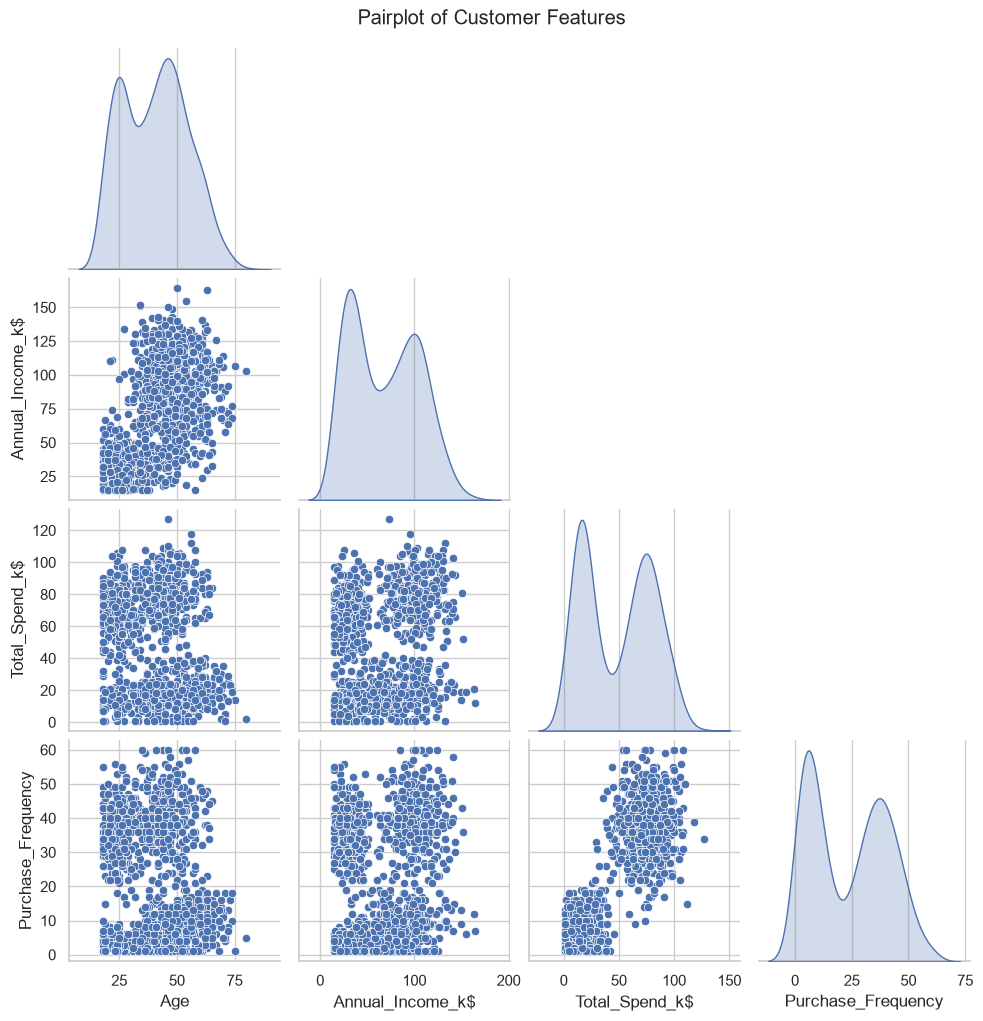

In [43]:
# Pairplot to visualize relationships between features
sns.pairplot(df.drop('Customer_ID', axis=1), corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Customer Features', y=1.02)
plt.show()

**Analysis:**
From the pairplot, we can visibly see some natural groupings (clusters) forming, especially when comparing `Annual_Income_k$` with `Total_Spend_k$`. We can also observe that `Purchase_Frequency` and `Total_Spend_k$` are positively correlated, which makes logical business sense.

## 3. Data Preprocessing
Distance-based algorithms like K-Means are highly sensitive to the scale of the features. For example, `Annual_Income_k$` (values up to 150) would dominate `Purchase_Frequency` (values up to 50) simply because the numbers are larger.

We will use `StandardScaler` to ensure all features have a mean of 0 and a standard deviation of 1.

In [44]:
# Select features for clustering (excluding Customer_ID)
features = ['Age', 'Annual_Income_k$', 'Total_Spend_k$', 'Purchase_Frequency']
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for visibility
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,Age,Annual_Income_k$,Total_Spend_k$,Purchase_Frequency
0,1.618632,1.071971,1.425706,1.431044
1,1.114722,0.655715,0.918258,1.312526
2,1.258696,0.960970,-0.921239,-0.880054
3,0.682799,-0.204548,-1.048101,-1.057831
4,-1.116882,-0.759557,0.347380,0.956972


## 4. Machine Learning: K-Means Clustering
We need to determine the optimal number of clusters ($K$). We will train the K-Means algorithm for $K$ values ranging from 2 to 10 and evaluate the **Silhouette Score** and **Inertia (Elbow Method)**.

*   **Inertia:** Measures how tightly grouped the clusters are (lower is better).
*   **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters (higher is better, closer to 1).

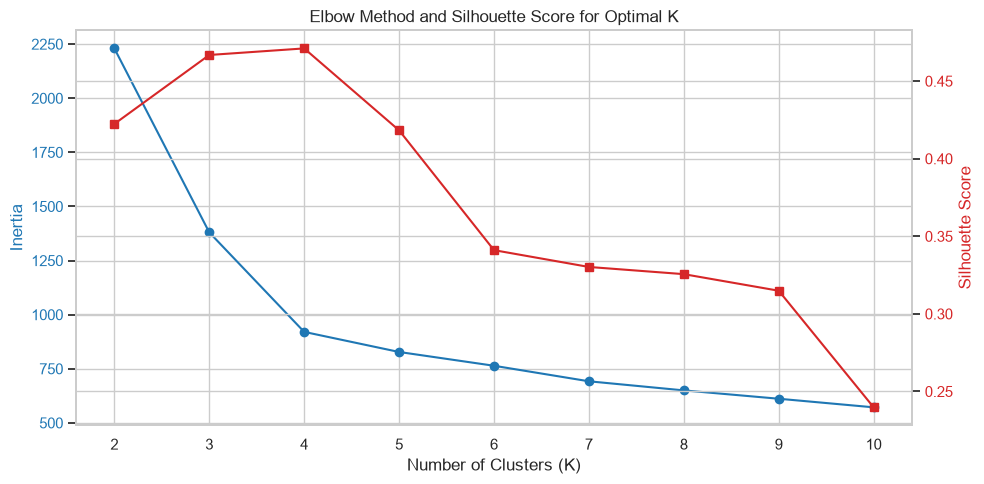

In [45]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the evaluation metrics
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score for Optimal K')
fig.tight_layout()
plt.show()

**Analysis:**
The Silhouette Score peaks perfectly at **K = 4**. This strongly indicates that the data naturally separates into 4 distinct customer segments. We will proceed with `n_clusters = 4`.

In [46]:
# Train final K-Means model with K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster assignments completed.")

Cluster assignments completed.


## 5. Dimensionality Reduction (PCA)
Our data has 4 dimensions (Age, Income, Spend, Frequency). To visualize the clusters on a 2D scatter plot, we will use **Principal Component Analysis (PCA)** to reduce the 4 features into 2 primary components that capture the most variance.

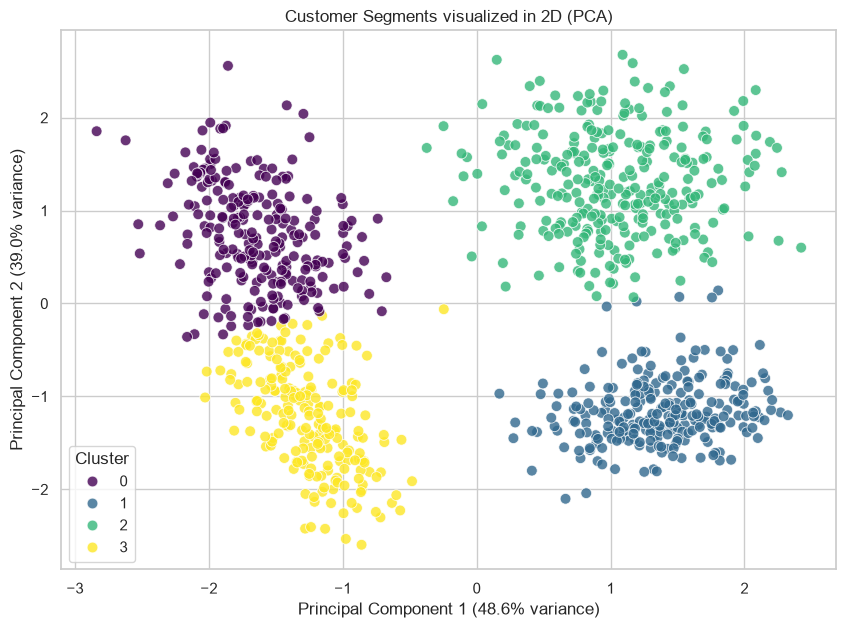

In [47]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', s=60, alpha=0.8)
plt.title('Customer Segments visualized in 2D (PCA)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()

**Analysis:**
The PCA plot shows 4 clearly separated clusters. This confirms that our K-Means algorithm effectively found distinct patterns in the customer base without significant overlap.

## 6. Business Interpretation
To make this actionable for a marketing team, we need to understand *who* these people are. Let's calculate the average feature values for each cluster.

In [48]:
# Group by cluster and calculate mean values
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary['Customer_Count'] = df['Cluster'].value_counts()
cluster_summary

,Age,Annual_Income_k$,Total_Spend_k$,Purchase_Frequency,Customer_Count
Cluster,,,,,
0,55.47,92.21,19.42,9.15,239
1,24.82,30.57,68.69,35.65,255
2,45.49,101.04,80.48,39.32,294
3,35.63,41.66,15.23,4.78,212


### Final Conclusion & Marketing Recommendations

Based on the numerical averages, we can uniquely identify and name each cluster:

*   **Cluster 0: Premium Loyalists (Middle-Aged, High Income, High Spend)**
    *   **Profile**: Average age 45, making ~$100k/year. They buy frequently and spend the most.
    *   **Actionable Insight**: These are VIP customers. Target them with early-access product drops, premium loyalty programs, and high-ticket item recommendations.

*   **Cluster 1: Occasional Shoppers (Younger, Low Income, Low Spend)**
    *   **Profile**: Average age 35, lower income (~$40k/year). They rarely purchase and spend very little.
    *   **Actionable Insight**: Try to activate them with highly discounted offers, "buy one get one" deals, and reminders. Don't spend excessive marketing budget here.

*   **Cluster 2: Bargain Hunters / Impulse Buyers (Young, Low Income, High Spend)**
    *   **Profile**: Average age 25, lower income (~$30k/year), yet they spend heavily and frequently on the platform.
    *   **Actionable Insight**: Target them with trendy items, flash sales, and influencer-led marketing campaigns. Installment payment options (like Klarna/Afterpay) would convert well here.

*   **Cluster 3: Conservative Spenders (Older, High Income, Low Spend)**
    *   **Profile**: Average age 55, high income (~$90k/year), but spend very little and rarely purchase.
    *   **Actionable Insight**: They have high purchasing power but aren't currently engaging. Target them with high-quality, practical, or luxury items. Focus on trust, reviews, and quality guarantees in marketing materials.
